In [1]:
import jax.random as jrandom
import jax.tree_util

from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree, Tsit5, VirtualSTLATree, STLAControlTerm, STLAMultiTerm, ShiftedEuler
import jax.numpy as jnp
import diffrax
import math
import matplotlib.pyplot as plt

In [2]:
def drift(t, y, args):
    gamma, u, grad_f = args
    x, v = y[0], y[1]
    d_x = v
    d_v = -gamma * v - u * grad_f(x)
    d_y = jnp.array([d_x, d_v], dtype=jnp.float32)
    return d_y

def diffusion(t, y, args):
    gamma, u, _ = args
    d_v = jnp.sqrt(2*gamma*u)
    d_y = jnp.array([0, d_v], dtype=jnp.float32)
    return d_y

t0, t1 = 1, 3
brownian_motion = VirtualSTLATree(t0, t1, tol=2**-7, shape=(), key=jrandom.PRNGKey(2))
# terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, brownian_motion))
terms = STLAMultiTerm(ODETerm(drift), STLAControlTerm(diffusion, brownian_motion))

solver = ShiftedEuler()
saveat = SaveAt(ts=jnp.linspace(t0, t1, 1000))
args = (1.0, 1.0, lambda x: x)
sol = diffeqsolve(terms, solver, t0, t1, dt0=0.01, y0=jnp.array([0, 0], dtype=jnp.float32), args=args, saveat=saveat)

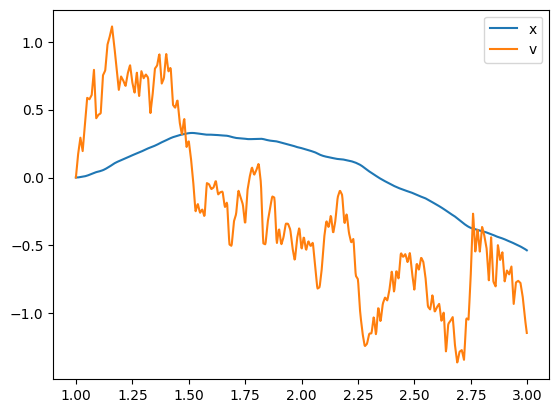

In [3]:
plt.plot(sol.ts, sol.ys[:,0], label="x")
plt.plot(sol.ts, sol.ys[:,1], label="v")
plt.legend()
plt.show()

In [38]:
import jax
vf = (jnp.array([1, 2, 3], dtype=jnp.float32), jnp.array([4, 5], dtype=jnp.float32))
control = jnp.ones(shape=(), dtype=jnp.float32)
def prod(vecF):
    jnp.tensordot(vecF, control, axes=jnp.ndim(control))
# out = jax.vmap(prod)(vf)
out = jax.tree_util.tree_map(lambda b, a: jnp.tensordot(a, b, axes=jnp.ndim(b)), control, vf)
print(out)

TypeError: tensordot requires ndarray or scalar arguments, got <class 'tuple'> at position 0.

In [43]:
tup = tuple(i**2 for i in (2,3,4)+(1,))
print(tup)
tup2 = tuple(filter(lambda x: x>5, tup))
print(tup2)

(4, 9, 16, 1)
(9, 16)
